# Chapter 6: Group Segmentation

**Book:** *Hands-On Unsupervised Learning Using Python* — Ankur A. Patel (O'Reilly, 2019)  
**Audience:** Beginners  
**Goal:** Apply **clustering** to real-world **group segmentation** — Lending Club borrower profiles. Prepare loan features, cluster without labels, then evaluate cluster quality against designated grade/default labels (evaluation only).

---

## What you will learn

1. What **group segmentation** means in lending and marketing
2. Prepare Lending Club–style loan data: explore, encode categoricals, impute missing values, engineer features, scale
3. Designate **evaluation labels** (loan grade tier, default status) — **not** used during clustering
4. **k-Means:** elbow/inertia method to choose k, segment borrowers
5. **Agglomerative hierarchical clustering:** dendrogram and flat clusters
6. **HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise):** density-based segments and noise points
7. Compare clustering algorithms with a summary table (purity/alignment vs evaluation labels)


## Setup — run this cell first

| Library | Purpose |
|---------|--------|
| **NumPy (Numerical Python)** | Arrays and math |
| **Pandas (Python Data Analysis Library)** | DataFrames (two-dimensional labeled data tables) |
| **Matplotlib (Mathematical Plotting Library)** | Histograms, inertia curves, dendrograms |
| **scikit-learn (Scientific Kit for Learning)** | Imputation, scaling, k-Means, AgglomerativeClustering |
| **SciPy (Scientific Python)** | Linkage and dendrogram for hierarchical clustering |
| **hdbscan** | HDBSCAN algorithm — density-based hierarchical clustering |


In [1]:
# Import warnings module so we can hide non-critical messages during demos
import warnings

# Hide sklearn (scikit-learn)/matplotlib warnings to keep notebook output clean for beginners
warnings.filterwarnings("ignore")

# Import NumPy (Numerical Python) for fast numerical operations on arrays
import numpy as np

# Import Pandas (Python Data Analysis Library) for working with labeled tables (DataFrames)
import pandas as pd

# Import Matplotlib (Mathematical Plotting Library) for creating charts
import matplotlib.pyplot as plt

# Import SimpleImputer to fill missing numeric values before clustering
from sklearn.impute import SimpleImputer

# Import StandardScaler to put loan features on comparable scale
from sklearn.preprocessing import StandardScaler

# Import clustering algorithms covered in Chapter 6
from sklearn.cluster import KMeans, AgglomerativeClustering

# Import SciPy (Scientific Python) hierarchy tools for dendrogram visualization
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Import silhouette score to measure cluster separation (optional evaluation metric)
from sklearn.metrics import silhouette_score

# Import HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)
import hdbscan

# Import display() for rich table output inside Jupyter (Julia, Python, and R notebook environment)
from IPython.display import display

# Confirm setup completed without errors
print("Libraries loaded successfully.")


Libraries loaded successfully.


---

## Libraries Imported in This Notebook

| Library | What it does | Why we use it here |
|---------|--------------|-------------------|
| **NumPy (Numerical Python)** (`np`) | Fast math on arrays | Synthetic loan data, cluster labels |
| **Pandas (Python Data Analysis Library)** (`pd`) | Spreadsheet-like DataFrames | Loan features, cluster results, summary tables |
| **Matplotlib (Mathematical Plotting Library)** (`plt`) | Charts and plots | Feature distributions, inertia curve, dendrogram |
| **sklearn.impute.SimpleImputer** | Fill missing values | Lending data often has incomplete fields |
| **sklearn.preprocessing.StandardScaler** | Feature scaling | Fair distance-based clustering on mixed magnitudes |
| **sklearn.cluster.KMeans** | Centroid-based clustering | Partition borrowers into k segments |
| **sklearn.cluster.AgglomerativeClustering** | Bottom-up hierarchical clustering | Alternative segment discovery |
| **scipy.cluster.hierarchy** | Linkage and dendrogram | Visualize hierarchical merge tree |
| **hdbscan** | Hierarchical DBSCAN | Multi-scale density segments on loan profiles |
| **sklearn.metrics.silhouette_score** | Cluster separation metric | Supplement label-based evaluation |


---

## Algorithms Used in This Notebook

### 1. k-Means (`KMeans`)
- **Type:** Centroid-based (center-based) partitioning clustering
- **Finds:** k borrower groups by minimizing Within-Cluster Sum of Squares (WCSS)
- **Key hyperparameters:** `n_clusters` (k), `n_init`, `max_iter`
- **Choosing k:** Elbow method — plot inertia vs k and look for a bend

### 2. Agglomerative Hierarchical Clustering
- **Type:** Bottom-up hierarchical clustering
- **Finds:** Nested clusters by repeatedly merging closest groups
- **Dendrogram (hierarchical cluster tree):** Diagram showing merge order
- **Flat clusters:** Cut tree with `fcluster` at a distance threshold

### 3. HDBSCAN (`hdbscan.HDBSCAN`)
- **Type:** Hierarchical Density-Based Spatial Clustering of Applications with Noise
- **Finds:** Clusters of varying density; sparse borrowers labeled **-1 (noise)**
- **Key hyperparameters:** `min_cluster_size`, `min_samples`

### Evaluation note (important for beginners)

Clustering is **unsupervised** — algorithms never see loan grade or default labels during fitting. We designate labels **only** to measure cluster **purity/alignment** (same `analyzeCluster` logic as Chapter 5). This teaches evaluation; in production you would use business KPIs (Key Performance Indicators) and expert review.


---

## 1. What Is Group Segmentation?

**Group segmentation** divides a population into **behavioral or risk profiles** without using labels during clustering.

| | Supervised credit scoring (Chapter 2) | Group segmentation (Chapter 6) |
|--|----------------------------------------|--------------------------------|
| **Labels in training?** | Yes — predict default | No — discover borrower groups |
| **Goal** | Predict outcome for new loans | Find natural segments for marketing, pricing, monitoring |
| **Lending Club example** | N/A here | Cluster on loan amount, income, DTI (Debt-to-Income), rate, etc. |

**Key terms:**

| Term | Meaning |
|------|--------|
| **Segment** | A cluster of similar borrowers |
| **Prime grade (A–D)** | Lower-risk loans in Lending Club grading |
| **Subprime grade (E–G)** | Higher-risk loans |
| **DTI (Debt-to-Income ratio)** | Monthly debt payments ÷ gross monthly income |
| **Loan-to-income ratio** | Loan amount ÷ annual income — engineered feature |


---

## 2. Lending Club Loan Data

### 2.1 Data Acquisition

The book uses **Lending Club** loan data from the author's GitHub repository. That CSV (Comma-Separated Values) file is **not available** in this course repo.

**Our approach:** We generate a **synthetic dataset** (~6,500 rows) mimicking common Lending Club fields:

| Column | Description |
|--------|-------------|
| `loan_amnt` | Loan amount requested (USD) |
| `int_rate` | Interest rate (percent) |
| `installment` | Monthly payment (USD) |
| `grade` | Letter grade A–G (risk tier) |
| `emp_length` | Employment length (years, with missing values) |
| `dti` | Debt-to-Income ratio (percent) |
| `annual_inc` | Annual income (USD) |
| `delinq_2yrs` | Delinquencies in past 2 years |
| `home_ownership` | RENT, MORTGAGE, or OWN |
| `purpose` | Loan purpose (e.g., debt_consolidation) |
| `revol_util` | Revolving credit utilization (percent) |
| `loan_status` | **Evaluation only:** Fully Paid vs Charged Off |

> In production you would load the real file with `pd.read_csv()`. The preparation and clustering workflow below is identical.


In [2]:
# Set random seed so the synthetic Lending Club data is reproducible
RNG = np.random.default_rng(42)

# Number of synthetic loan records (between 5,000–8,000 as in course spec)
N_SAMPLES = 6500

# Random seed used for clustering experiments (matches book chapters)
RANDOM_STATE = 2018

# Grade letters A through G with ordinal risk (1 = best, 7 = worst)
GRADE_ORDER = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}

# Home ownership categories seen in real Lending Club exports
HOME_OPTS = ["RENT", "MORTGAGE", "OWN"]

# Common loan purpose strings for categorical encoding demo
PURPOSE_OPTS = ["debt_consolidation", "credit_card", "home_improvement", "other"]

# Define four latent borrower segments (low → very high risk) for realistic structure
SEGMENT_NAMES = ["low_risk", "medium_risk", "high_risk", "very_high_risk"]

# Assign each loan to one segment (roughly balanced quarters)
segment_idx = RNG.integers(0, 4, size=N_SAMPLES)

# Initialize empty lists to collect column values row by row
loan_amnt_list = []

int_rate_list = []

installment_list = []

grade_list = []

emp_length_list = []

dti_list = []

annual_inc_list = []

delinq_list = []

home_list = []

purpose_list = []

revol_list = []

status_list = []

# Loop each segment and draw feature values from segment-specific distributions
for seg in range(4):

    mask = segment_idx == seg

    n_seg = mask.sum()

    # Loan amount increases with risk segment
    loan_amnt_list.append(RNG.normal(8000 + seg * 4000, 2500, n_seg).clip(1000, 40000))

    # Interest rate rises with risk segment
    int_rate_list.append(RNG.normal(7 + seg * 3, 1.5, n_seg).clip(5, 25))

    # Installment correlates with amount and rate (simplified monthly payment proxy)
    installment_list.append(RNG.normal(200 + seg * 80, 60, n_seg).clip(50, 800))

    # Grade letters weighted by segment risk
    grade_probs = [0.35, 0.25, 0.20, 0.10, 0.05, 0.03, 0.02]

    grade_probs = np.array(grade_probs) + seg * np.array([0, 0, 0, 0.02, 0.03, 0.02, 0.01])

    grade_probs = grade_probs / grade_probs.sum()

    grades = RNG.choice(list(GRADE_ORDER.keys()), size=n_seg, p=grade_probs)

    grade_list.append(grades)

    # Employment length in years — inject ~8% missing for imputation exercise
    emp = RNG.integers(0, 11, size=n_seg)

    miss_emp = RNG.random(n_seg) < 0.08

    emp[miss_emp] = -1

    emp_length_list.append(emp)

    # DTI (Debt-to-Income) rises with risk
    dti_list.append(RNG.normal(12 + seg * 5, 6, n_seg).clip(0, 45))

    # Annual income — lower in higher-risk segments
    annual_inc_list.append(RNG.lognormal(mean=10.5 - seg * 0.15, sigma=0.5, size=n_seg).clip(20000, 250000))

    # Delinquencies — more common in risky segments
    delinq_list.append(RNG.poisson(lam=0.2 + seg * 0.4, size=n_seg).clip(0, 5))

    # Home ownership — categorical strings
    home_list.append(RNG.choice(HOME_OPTS, size=n_seg, p=[0.35, 0.55, 0.10]))

    # Loan purpose — categorical strings
    purpose_list.append(RNG.choice(PURPOSE_OPTS, size=n_seg, p=[0.55, 0.25, 0.12, 0.08]))

    # Revolving utilization percent
    revol_list.append(RNG.normal(45 + seg * 8, 15, n_seg).clip(0, 100))

    # Loan status for evaluation — higher charge-off rate in risky segments
    charge_prob = 0.03 + seg * 0.08

    status = RNG.choice(["Fully Paid", "Charged Off"], size=n_seg, p=[1 - charge_prob, charge_prob])

    status_list.append(status)

# Concatenate segment arrays into single columns
loan_amnt = np.concatenate(loan_amnt_list)

int_rate = np.concatenate(int_rate_list)

installment = np.concatenate(installment_list)

grade = np.concatenate(grade_list)

emp_length = np.concatenate(emp_length_list)

dti = np.concatenate(dti_list)

annual_inc = np.concatenate(annual_inc_list)

delinq_2yrs = np.concatenate(delinq_list)

home_ownership = np.concatenate(home_list)

purpose = np.concatenate(purpose_list)

revol_util = np.concatenate(revol_list)

loan_status = np.concatenate(status_list)

# Shuffle rows so segments are mixed (clustering should discover structure)
shuffle = RNG.permutation(N_SAMPLES)

loan_amnt = loan_amnt[shuffle]

int_rate = int_rate[shuffle]

installment = installment[shuffle]

grade = grade[shuffle]

emp_length = emp_length[shuffle]

dti = dti[shuffle]

annual_inc = annual_inc[shuffle]

delinq_2yrs = delinq_2yrs[shuffle]

home_ownership = home_ownership[shuffle]

purpose = purpose[shuffle]

revol_util = revol_util[shuffle]

loan_status = loan_status[shuffle]

# Build raw DataFrame (two-dimensional labeled data table) like a Lending Club CSV
df_raw = pd.DataFrame({
    "loan_amnt": loan_amnt,
    "int_rate": int_rate,
    "installment": installment,
    "grade": grade,
    "emp_length": emp_length,
    "dti": dti,
    "annual_inc": annual_inc,
    "delinq_2yrs": delinq_2yrs,
    "home_ownership": home_ownership,
    "purpose": purpose,
    "revol_util": revol_util,
    "loan_status": loan_status,
})

# Report shape and charge-off rate for sanity check
print(f"Synthetic Lending Club stand-in: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

print(f"Charge-off rate: {(df_raw['loan_status'] == 'Charged Off').mean():.2%}")

display(df_raw.head())


Synthetic Lending Club stand-in: 6500 rows, 12 columns
Charge-off rate: 14.18%


,loan_amnt,int_rate,installment,grade,emp_length,dti,annual_inc,delinq_2yrs,home_ownership,purpose,revol_util,loan_status
0,24507.412649,17.408117,431.819646,B,5,29.977671,20839.112875,1,MORTGAGE,debt_consolidation,79.170866,Fully Paid
1,12492.391871,6.034758,266.726051,C,4,15.347042,82519.888065,0,MORTGAGE,debt_consolidation,34.324774,Fully Paid
2,16259.240747,12.391730,213.609433,C,3,17.442034,28329.613302,1,MORTGAGE,debt_consolidation,67.518718,Fully Paid
3,4505.840298,5.937233,285.040003,E,5,15.163095,43141.415810,0,RENT,debt_consolidation,74.264774,Fully Paid
4,6916.432538,7.792028,198.654542,E,9,16.895743,26556.422361,0,MORTGAGE,other,49.598265,Charged Off


### 2.2 Explore the Data

Before clustering we inspect distributions, missing values, and categorical levels — same workflow as the book.


In [3]:
# Summary statistics for numeric loan features
display(df_raw.describe())

# Count missing employment length (-1 is our synthetic missing marker)
n_missing_emp = (df_raw["emp_length"] < 0).sum()

print(f"Missing emp_length (synthetic -1 marker): {n_missing_emp} ({n_missing_emp/len(df_raw):.1%})")

# Value counts for grade and loan status (evaluation columns)
print("Grade distribution:")

print(df_raw["grade"].value_counts().sort_index())

print("Loan status distribution:")

print(df_raw["loan_status"].value_counts())


,loan_amnt,int_rate,installment,emp_length,dti,annual_inc,delinq_2yrs,revol_util
count,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000,6500.000000
mean,13984.976248,11.487595,317.182894,4.492000,19.358106,34522.581600,0.818000,56.771485
std,5176.323178,3.621678,107.818000,3.432164,8.128614,17797.158970,1.002973,17.440985
min,1000.000000,5.000000,50.000000,-1.000000,0.000000,20000.000000,0.000000,0.000000
25%,9887.749341,8.486486,235.206347,2.000000,13.454929,20318.836145,0.000000,44.646767
50%,13992.223408,11.481426,315.051618,5.000000,19.317562,29010.550222,1.000000,56.868885
75%,18046.432577,14.460716,400.050261,7.000000,25.147707,41525.243038,1.000000,68.843212
max,29067.510514,20.612700,673.450535,10.000000,45.000000,218097.216164,5.000000,100.000000


Missing emp_length (synthetic -1 marker): 536 (8.2%)


Grade distribution:
grade
A    1977
B    1496
C    1233
D     714
E     541
F     361
G     178
Name: count, dtype: int64
Loan status distribution:
loan_status
Fully Paid     5578
Charged Off     922
Name: count, dtype: int64


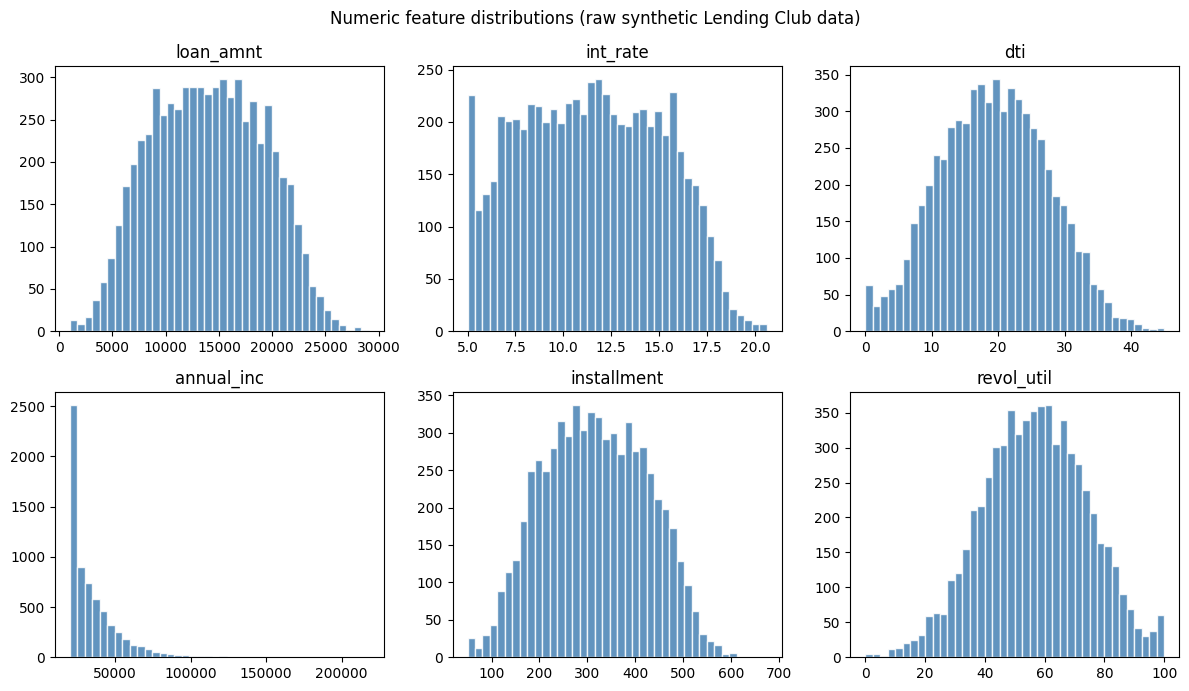

In [4]:
# Histograms of key numeric features — spot skew and scale differences
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

num_cols = ["loan_amnt", "int_rate", "dti", "annual_inc", "installment", "revol_util"]

for ax, col in zip(axes.flat, num_cols):

    ax.hist(df_raw[col], bins=40, color="steelblue", edgecolor="white", alpha=0.85)

    ax.set_title(col)

plt.suptitle("Numeric feature distributions (raw synthetic Lending Club data)")

plt.tight_layout()

plt.show()


---

## 3. Data Preparation for Clustering

Following the book pipeline:
1. Encode categoricals (grade ordinal, one-hot home/purpose)
2. Impute missing `emp_length`
3. Engineer `loan_to_income` ratio
4. Select final modeling features (exclude evaluation labels)
5. **StandardScaler** on the feature matrix


In [5]:
# Work on a copy so raw table stays available for reference
df = df_raw.copy()

# Replace synthetic missing marker -1 with NaN (Not a Number) for imputer
df.loc[df["emp_length"] < 0, "emp_length"] = np.nan

# Encode grade as ordinal integer 1–7 (A=1 best, G=7 worst)
df["grade_encoded"] = df["grade"].map(GRADE_ORDER)

# One-hot encode home_ownership — drop_first avoids redundant dummy column
home_dummies = pd.get_dummies(df["home_ownership"], prefix="home", drop_first=True)

# One-hot encode purpose — same encoding strategy
purpose_dummies = pd.get_dummies(df["purpose"], prefix="purpose", drop_first=True)

# Concatenate encoded columns into working DataFrame
df = pd.concat([df, home_dummies, purpose_dummies], axis=1)

# Engineer loan_to_income — loan amount divided by annual income (book-style ratio)
df["loan_to_income"] = df["loan_amnt"] / df["annual_inc"].replace(0, np.nan)

# List numeric columns that will be imputed then scaled for clustering
NUMERIC_CLUSTER_COLS = [
    "loan_amnt",
    "int_rate",
    "installment",
    "grade_encoded",
    "emp_length",
    "dti",
    "annual_inc",
    "delinq_2yrs",
    "revol_util",
    "loan_to_income",
]

# Gather dummy column names dynamically after get_dummies
DUMMY_COLS = list(home_dummies.columns) + list(purpose_dummies.columns)

# Final feature list for clustering — numeric + dummies, no labels
FEATURE_COLS = NUMERIC_CLUSTER_COLS + DUMMY_COLS

# Impute missing numeric values with median (robust to skewed income)
imputer = SimpleImputer(strategy="median")

df[NUMERIC_CLUSTER_COLS] = imputer.fit_transform(df[NUMERIC_CLUSTER_COLS])

print(f"Features for clustering ({len(FEATURE_COLS)} columns):")

print(FEATURE_COLS)

display(df[FEATURE_COLS].head())


Features for clustering (15 columns):
['loan_amnt', 'int_rate', 'installment', 'grade_encoded', 'emp_length', 'dti', 'annual_inc', 'delinq_2yrs', 'revol_util', 'loan_to_income', 'home_OWN', 'home_RENT', 'purpose_debt_consolidation', 'purpose_home_improvement', 'purpose_other']


,loan_amnt,int_rate,installment,grade_encoded,emp_length,dti,annual_inc,delinq_2yrs,revol_util,loan_to_income,home_OWN,home_RENT,purpose_debt_consolidation,purpose_home_improvement,purpose_other
0,24507.412649,17.408117,431.819646,2.0,5.0,29.977671,20839.112875,1.0,79.170866,1.176030,False,False,True,False,False
1,12492.391871,6.034758,266.726051,3.0,4.0,15.347042,82519.888065,0.0,34.324774,0.151386,False,False,True,False,False
2,16259.240747,12.391730,213.609433,3.0,3.0,17.442034,28329.613302,1.0,67.518718,0.573931,False,False,True,False,False
3,4505.840298,5.937233,285.040003,5.0,5.0,15.163095,43141.415810,0.0,74.264774,0.104443,False,True,True,False,False
4,6916.432538,7.792028,198.654542,5.0,9.0,16.895743,26556.422361,0.0,49.598265,0.260443,False,False,False,False,True


In [6]:
# Extract feature matrix X — labels are NOT included
X_features = df[FEATURE_COLS].copy()

# StandardScaler fit on all rows (book uses full training set for segmentation demo)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_features)

# Store scaled features in DataFrame for readable column names in plots
X_cluster = pd.DataFrame(X_scaled, columns=FEATURE_COLS, index=df.index)

print(f"Scaled feature matrix shape: {X_cluster.shape}")

display(X_cluster.describe().T.head(10))


Scaled feature matrix shape: (6500, 15)


,count,mean,std,min,25%,50%,75%,max
loan_amnt,6500.0,-2.186285e-17,1.000077,-2.508726,-0.791593,0.001400,0.784682,2.913979
int_rate,6500.0,3.607371e-16,1.000077,-1.791461,-0.828715,-0.001703,0.820987,2.519773
installment,6500.0,-1.858343e-16,1.000077,-2.478282,-0.760382,-0.019769,0.768645,3.304597
grade_encoded,6500.0,2.186285e-17,1.000077,-1.034382,-1.034382,-0.430892,0.776088,2.586558
emp_length,6500.0,-6.941456e-17,1.000077,-1.656084,-0.659797,0.004394,0.668585,1.664872
dti,6500.0,1.268045e-16,1.000077,-2.381660,-0.726278,-0.004988,0.712304,3.154765
annual_inc,6500.0,6.340227e-17,1.000077,-0.816068,-0.798152,-0.309738,0.393501,10.315622
delinq_2yrs,6500.0,-1.639714e-17,1.000077,-0.815638,-0.815638,0.181475,0.181475,4.169927
revol_util,6500.0,5.848313e-17,1.000077,-3.255312,-0.695239,0.005585,0.692200,2.478750
loan_to_income,6500.0,7.979941e-17,1.000077,-1.674492,-0.827041,-0.180025,0.730400,3.112596


---

## 4. Designate Labels for Evaluation Only

The book creates **evaluation labels** after clustering prep. These are **never** fed to k-Means, hierarchical, or HDBSCAN.

| Label | Definition | Use |
|-------|------------|-----|
| `grade_tier` | **prime** = grades A–D, **subprime** = E–G | Measure if clusters separate risk tiers |
| `default_flag` | 1 = Charged Off, 0 = Fully Paid | Measure alignment with default outcome |
| `grade` (letter) | A–G | Fine-grained purity via `analyzeCluster` |


In [7]:
# Prime vs subprime tier — A-D vs E-G as in course specification
grade_tier = df["grade"].apply(lambda g: "prime" if g in ["A", "B", "C", "D"] else "subprime")

# Binary default flag from loan_status for evaluation only
default_flag = (df["loan_status"] == "Charged Off").astype(int)

# Store evaluation Series (one-dimensional labeled column) with row index aligned to X_cluster
eval_grade_tier = pd.Series(grade_tier.values, index=df.index, name="grade_tier")

eval_default = pd.Series(default_flag.values, index=df.index, name="default_flag")

eval_grade = pd.Series(df["grade"].values, index=df.index, name="grade")

print("Evaluation label distributions (NOT used in clustering):")

print(eval_grade_tier.value_counts())

print(eval_default.value_counts())

print(eval_grade.value_counts().sort_index())


Evaluation label distributions (NOT used in clustering):
grade_tier
prime       5420
subprime    1080
Name: count, dtype: int64
default_flag
0    5578
1     922
Name: count, dtype: int64
grade
A    1977
B    1496
C    1233
D     714
E     541
F     361
G     178
Name: count, dtype: int64


---

## 5. Helper — Evaluate Clusters Against Designated Labels

Same `analyzeCluster` logic as Chapter 5: for each cluster, assign the **most frequent** evaluation label and compute alignment accuracy.


In [8]:
# Define analyzeCluster — same logic as Chapter 5 helper
def analyzeCluster(clusterDF, labelsDF):

    # Count how many points fall in each cluster
    countByCluster = pd.DataFrame(clusterDF["cluster"].value_counts()).reset_index()

    countByCluster.columns = ["cluster", "clusterCount"]

    # Combine evaluation labels with cluster assignments
    preds = pd.concat([labelsDF, clusterDF], axis=1)

    preds.columns = ["trueLabel", "cluster"]

    # For each cluster, count points matching the most frequent label in that cluster
    countMostFreq = preds.groupby("cluster").agg(lambda x: x.value_counts().iloc[0])

    countMostFreq = countMostFreq.reset_index()

    countMostFreq.columns = ["cluster", "countMostFrequent"]

    # Merge counts to compute accuracy per cluster
    accuracyDF = countMostFreq.merge(countByCluster, on="cluster")

    overallAccuracy = accuracyDF["countMostFrequent"].sum() / accuracyDF["clusterCount"].sum()

    accuracyByLabel = accuracyDF["countMostFrequent"] / accuracyDF["clusterCount"]

    return countByCluster, countMostFreq, accuracyDF, overallAccuracy, accuracyByLabel


---

## 6. k-Means Application

### 6.1 Elbow Method — Inertia vs k

Plot **inertia (Within-Cluster Sum of Squares, WCSS)** vs number of clusters k. Look for an **elbow** where adding clusters helps less.


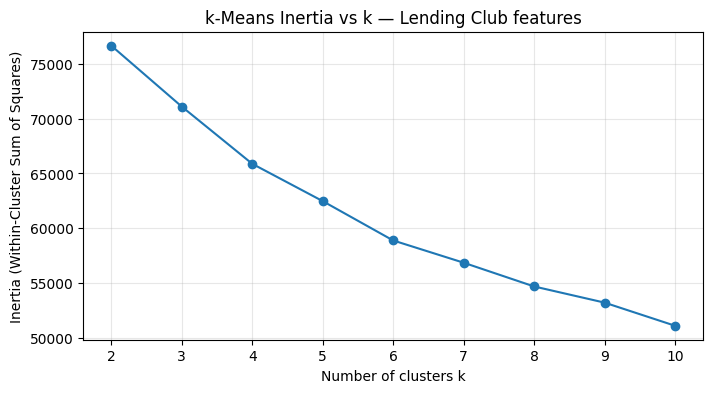

,k,inertia
0,2,76666.878516
1,3,71105.238854
2,4,65880.713512
3,5,62472.291041
4,6,58878.377318
5,7,56847.197838
6,8,54677.779506
7,9,53200.907689
8,10,51089.982982


In [9]:
# Sweep k from 2 to 10 and record k-Means inertia for each k
k_range = range(2, 11)

inertia_rows = []

for n_clusters in k_range:

    # Fit k-Means on scaled loan features
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)

    kmeans.fit(X_cluster)

    inertia_rows.append({"k": n_clusters, "inertia": kmeans.inertia_})

inertia_df = pd.DataFrame(inertia_rows)

plt.figure(figsize=(8, 4))

plt.plot(inertia_df["k"], inertia_df["inertia"], marker="o")

plt.xlabel("Number of clusters k")

plt.ylabel("Inertia (Within-Cluster Sum of Squares)")

plt.title("k-Means Inertia vs k — Lending Club features")

plt.grid(True, alpha=0.3)

plt.show()

display(inertia_df)


### 6.2 Fit k-Means at Chosen k and Evaluate vs Grade Tier

We choose **k = 4** (matches four latent risk segments in our synthetic data — elbow often bends around 3–5).


In [10]:
# Set number of clusters for main k-Means segmentation
K_CHOSEN = 4

# Fit k-Means with chosen k on scaled features
kmeans_final = KMeans(n_clusters=K_CHOSEN, n_init=10, max_iter=300, random_state=RANDOM_STATE)

km_labels = kmeans_final.fit_predict(X_cluster)

# Build cluster assignment DataFrame aligned with evaluation labels
clusterDF_km = pd.DataFrame({"cluster": km_labels}, index=df.index)

# Evaluate alignment with prime/subprime tier (evaluation only)
countByCluster, countMostFreq, accuracyDF, overall_acc_km_tier, acc_by = analyzeCluster(clusterDF_km, eval_grade_tier)

print(f"k-Means (k={K_CHOSEN}) — alignment with grade_tier: {overall_acc_km_tier:.2%}")

# Also check alignment with letter grade and default flag
_, _, _, overall_acc_km_grade, _ = analyzeCluster(clusterDF_km, eval_grade)

_, _, _, overall_acc_km_default, _ = analyzeCluster(clusterDF_km, eval_default)

print(f"k-Means alignment with letter grade: {overall_acc_km_grade:.2%}")

print(f"k-Means alignment with default_flag: {overall_acc_km_default:.2%}")

# Silhouette score on scaled features — higher means better separation
sil_km = silhouette_score(X_cluster, km_labels)

print(f"Silhouette score (k-Means): {sil_km:.3f}")

display(accuracyDF)


k-Means (k=4) — alignment with grade_tier: 83.38%
k-Means alignment with letter grade: 30.42%
k-Means alignment with default_flag: 85.82%


Silhouette score (k-Means): 0.199


,cluster,countMostFrequent,clusterCount
0,0,459,543
1,1,2015,2562
2,2,2293,2597
3,3,653,798


k-Means cluster centers (inverse-scaled) — loan_amnt and int_rate by cluster:


,loan_amnt,int_rate,dti,annual_inc,grade_encoded
0,13595.202812,11.104931,18.314012,35387.844853,2.718232
1,18109.654716,14.419903,24.671247,28328.524996,2.929715
2,10045.483503,8.690517,14.407703,40319.216845,2.495381
3,13838.544629,11.443675,19.133969,34940.479660,2.730576


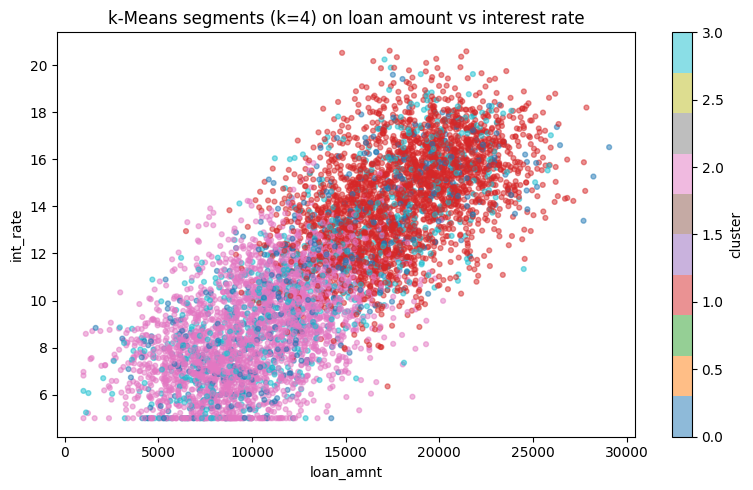

In [11]:
# Visualize cluster centers in original scale for two key business features
centers_scaled = kmeans_final.cluster_centers_

centers_original = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(centers_original, columns=FEATURE_COLS)

print("k-Means cluster centers (inverse-scaled) — loan_amnt and int_rate by cluster:")

display(centers_df[["loan_amnt", "int_rate", "dti", "annual_inc", "grade_encoded"]])

# Scatter loan amount vs interest rate colored by k-Means cluster
plt.figure(figsize=(8, 5))

scatter = plt.scatter(df_raw["loan_amnt"], df_raw["int_rate"], c=km_labels, cmap="tab10", alpha=0.5, s=12)

plt.xlabel("loan_amnt")

plt.ylabel("int_rate")

plt.title(f"k-Means segments (k={K_CHOSEN}) on loan amount vs interest rate")

plt.colorbar(scatter, label="cluster")

plt.tight_layout()

plt.show()


---

## 7. Hierarchical Clustering Application

**Agglomerative hierarchical clustering** merges closest clusters step by step. We plot a **dendrogram** on a subsample (linkage is expensive on 6,500 points).


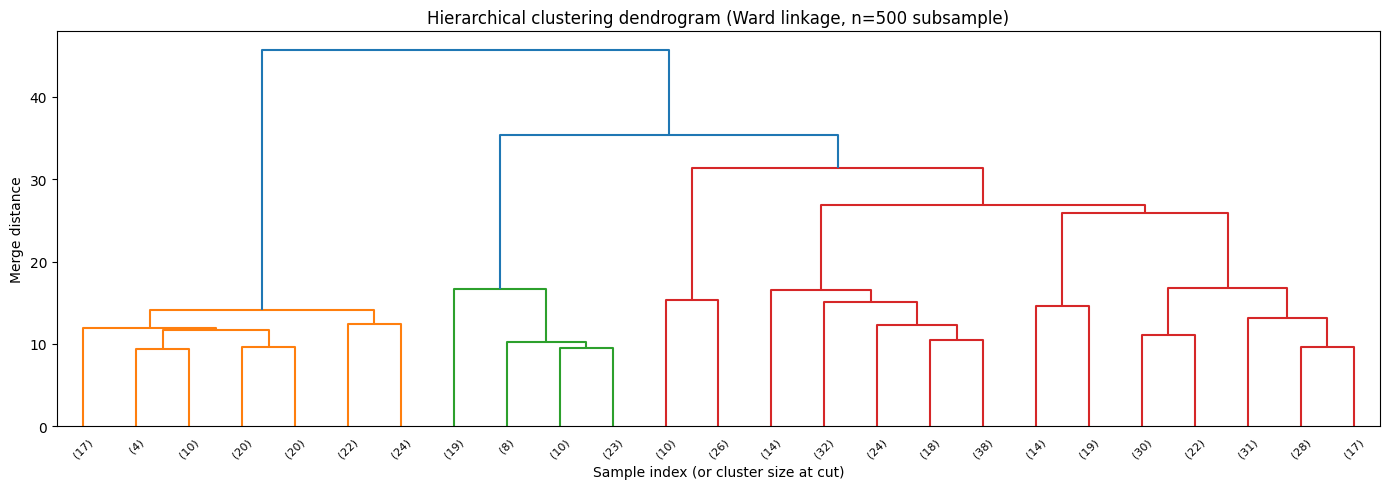

In [12]:
# Subsample for dendrogram — linkage memory grows with n^2
N_DENDRO = 500

rng = np.random.RandomState(RANDOM_STATE)

d_idx = rng.choice(len(X_cluster), size=N_DENDRO, replace=False)

X_dendro = X_cluster.iloc[d_idx].values

# Ward linkage minimizes variance when merging — common for Euclidean scaled data
Z = linkage(X_dendro, method="ward")

plt.figure(figsize=(14, 5))

dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=45, leaf_font_size=8)

plt.title("Hierarchical clustering dendrogram (Ward linkage, n=500 subsample)")

plt.xlabel("Sample index (or cluster size at cut)")

plt.ylabel("Merge distance")

plt.tight_layout()

plt.show()


In [13]:
# Cut dendrogram to form flat clusters (book uses fcluster)
distance_threshold = 18

hier_labels_sub = fcluster(Z, t=distance_threshold, criterion="distance")

clusterDF_hier_sub = pd.DataFrame({"cluster": hier_labels_sub}, index=d_idx)

eval_tier_sub = eval_grade_tier.iloc[d_idx]

countByCluster, _, accuracyDF_hier, overall_acc_hier, _ = analyzeCluster(clusterDF_hier_sub, eval_tier_sub)

print(f"Hierarchical clusters at distance={distance_threshold}: {len(np.unique(hier_labels_sub))} groups")

print(f"Alignment with grade_tier (subsample): {overall_acc_hier:.2%}")

display(countByCluster.head(10))


Hierarchical clusters at distance=18: 6 groups
Alignment with grade_tier (subsample): 83.00%


,cluster,clusterCount
0,6,128
1,4,126
2,1,117
3,2,60
4,3,36
5,5,33


In [14]:
# Full-dataset AgglomerativeClustering with same target k as k-Means for fair comparison
agg = AgglomerativeClustering(n_clusters=K_CHOSEN, linkage="ward")

agg_labels = agg.fit_predict(X_cluster)

clusterDF_agg = pd.DataFrame({"cluster": agg_labels}, index=df.index)

_, _, _, overall_acc_agg, _ = analyzeCluster(clusterDF_agg, eval_grade_tier)

sil_agg = silhouette_score(X_cluster, agg_labels)

print(f"Agglomerative (k={K_CHOSEN}) — alignment with grade_tier: {overall_acc_agg:.2%}")

print(f"Silhouette score (Agglomerative): {sil_agg:.3f}")


Agglomerative (k=4) — alignment with grade_tier: 83.38%
Silhouette score (Agglomerative): 0.142


---

## 8. HDBSCAN Application

HDBSCAN finds **density-based** segments and marks sparse borrowers as **noise (-1)**. It can discover non-spherical groups without fixing k manually.


In [15]:
# Configure HDBSCAN — min_cluster_size controls smallest allowed segment
hdb = hdbscan.HDBSCAN(min_cluster_size=80, min_samples=15, cluster_selection_method="eom")

# Fit on scaled loan features
hdb_labels = hdb.fit_predict(X_cluster)

clusterDF_hdb = pd.DataFrame({"cluster": hdb_labels}, index=df.index)

n_clusters_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)

n_noise_hdb = (hdb_labels == -1).sum()

print(f"HDBSCAN found {n_clusters_hdb} clusters and {n_noise_hdb} noise points ({n_noise_hdb/len(hdb_labels):.1%})")

# Evaluate alignment excluding noise points (density methods often leave outliers unassigned)
mask_hdb = clusterDF_hdb["cluster"] != -1

_, _, _, overall_acc_hdb, _ = analyzeCluster(clusterDF_hdb[mask_hdb], eval_grade_tier[mask_hdb])

print(f"HDBSCAN alignment with grade_tier (excluding noise): {overall_acc_hdb:.2%}")

print(clusterDF_hdb["cluster"].value_counts().head(10))


HDBSCAN found 4 clusters and 157 noise points (2.4%)
HDBSCAN alignment with grade_tier (excluding noise): 83.76%
cluster
 3    4585
 2     689
 1     559
 0     510
-1     157
Name: count, dtype: int64


In [16]:
# Silhouette on non-noise HDBSCAN points when at least 2 clusters exist
if n_clusters_hdb >= 2 and mask_hdb.sum() > n_clusters_hdb:

    sil_hdb = silhouette_score(X_cluster[mask_hdb], hdb_labels[mask_hdb])

    print(f"Silhouette score (HDBSCAN, excluding noise): {sil_hdb:.3f}")

else:

    sil_hdb = None

    print("Silhouette skipped — need at least 2 HDBSCAN clusters with enough points")


Silhouette score (HDBSCAN, excluding noise): 0.186


---

## 9. Compare Clustering Algorithms


In [17]:
# Build summary table comparing all Chapter 6 clustering methods
summary_rows = []

summary_rows.append({
    "Algorithm": f"k-Means (k={K_CHOSEN})",
    "Grade tier alignment": overall_acc_km_tier,
    "Letter grade alignment": overall_acc_km_grade,
    "Default alignment": overall_acc_km_default,
    "Silhouette": sil_km,
    "Notes": "Centroid-based, elbow k",
})

summary_rows.append({
    "Algorithm": f"Agglomerative (k={K_CHOSEN})",
    "Grade tier alignment": overall_acc_agg,
    "Letter grade alignment": analyzeCluster(clusterDF_agg, eval_grade)[3],
    "Default alignment": analyzeCluster(clusterDF_agg, eval_default)[3],
    "Silhouette": sil_agg,
    "Notes": "Ward linkage",
})

summary_rows.append({
    "Algorithm": "Hierarchical (fcluster subsample)",
    "Grade tier alignment": overall_acc_hier,
    "Letter grade alignment": analyzeCluster(clusterDF_hier_sub, eval_grade_tier.iloc[d_idx])[3],
    "Default alignment": analyzeCluster(clusterDF_hier_sub, eval_default.iloc[d_idx])[3],
    "Silhouette": None,
    "Notes": f"n={N_DENDRO} dendrogram cut",
})

hdb_grade_acc = analyzeCluster(clusterDF_hdb[mask_hdb], eval_grade[mask_hdb])[3] if mask_hdb.any() else 0.0

hdb_default_acc = analyzeCluster(clusterDF_hdb[mask_hdb], eval_default[mask_hdb])[3] if mask_hdb.any() else 0.0

summary_rows.append({
    "Algorithm": "HDBSCAN",
    "Grade tier alignment": overall_acc_hdb,
    "Letter grade alignment": hdb_grade_acc,
    "Default alignment": hdb_default_acc,
    "Silhouette": sil_hdb,
    "Notes": f"{n_noise_hdb} noise points",
})

summary_df = pd.DataFrame(summary_rows)

# Format percentages for readability in display table
for col in ["Grade tier alignment", "Letter grade alignment", "Default alignment"]:

    summary_df[col] = summary_df[col].map(lambda x: f"{x:.2%}" if x is not None else "—")

summary_df["Silhouette"] = summary_df["Silhouette"].map(lambda x: f"{x:.3f}" if x is not None else "—")

print("Clustering comparison — label alignment is for teaching evaluation only:")

display(summary_df)


Clustering comparison — label alignment is for teaching evaluation only:


,Algorithm,Grade tier alignment,Letter grade alignment,Default alignment,Silhouette,Notes
0,k-Means (k=4),83.38%,30.42%,85.82%,0.199,"Centroid-based, elbow k"
1,Agglomerative (k=4),83.38%,30.42%,85.82%,0.142,Ward linkage
2,Hierarchical (fcluster subsample),83.00%,83.00%,87.40%,nan,n=500 dendrogram cut
3,HDBSCAN,83.76%,30.43%,85.89%,0.186,157 noise points


---

## 10. Glossary — All Chapter 6 Terms

| Term | One-line definition |
|------|---------------------|
| **Group segmentation** | Dividing users/borrowers into behavioral clusters without labels in training |
| **Lending Club** | Peer-to-peer lending platform; book uses its loan dataset |
| **loan_amnt** | Dollar amount of the loan |
| **int_rate** | Interest rate charged on the loan (percent) |
| **installment** | Monthly payment amount |
| **grade (A–G)** | Lending Club risk letter grade |
| **emp_length** | Length of employment in years |
| **DTI (Debt-to-Income ratio)** | Monthly debt obligations ÷ gross monthly income |
| **annual_inc** | Borrower's stated annual income |
| **delinq_2yrs** | Number of delinquencies in the past 2 years |
| **revol_util** | Revolving credit line utilization (percent) |
| **loan_to_income** | Engineered ratio: loan amount ÷ annual income |
| **Prime grade (A–D)** | Lower-risk loan tier for evaluation |
| **Subprime grade (E–G)** | Higher-risk loan tier for evaluation |
| **SimpleImputer** | sklearn tool to fill missing values (median/mean/most_frequent) |
| **One-hot encoding** | Convert categories to binary dummy columns |
| **StandardScaler** | Scale features to zero mean and unit variance |
| **k-Means** | Partition data into k centroid-based clusters |
| **Inertia (WCSS)** | Within-Cluster Sum of Squares — k-Means objective |
| **Elbow method** | Pick k where inertia curve bends |
| **Hierarchical clustering** | Nested clusters via sequential merging |
| **Dendrogram** | Tree diagram of hierarchical merges |
| **HDBSCAN** | Hierarchical Density-Based Spatial Clustering of Applications with Noise |
| **Noise point** | Outlier labeled -1 by density-based clustering |
| **Cluster purity / alignment** | How well clusters match designated evaluation labels |
| **Silhouette score** | Cluster separation metric from -1 to 1 |


---

## 11. Chapter 6 Summary

```
Group Segmentation (Chapter 6) — Lending Club borrowers
├── Synthetic loan data (or pd.read_csv in production)
├── Explore → encode categoricals → impute → engineer loan_to_income
├── Select features → StandardScaler (labels excluded)
├── Designate evaluation labels: grade_tier, default_flag, letter grade
├── k-Means
│   ├── Inertia vs k (elbow method)
│   └── Segment at chosen k; evaluate with analyzeCluster
├── Hierarchical
│   ├── Dendrogram on subsample
│   └── AgglomerativeClustering on full data
├── HDBSCAN — density segments + noise points
└── Summary table: alignment + silhouette

Labels used ONLY for evaluation — never during clustering
```

### What's next?

**Chapter 7** introduces **autoencoders** with TensorFlow and Keras — neural network unsupervised learning.

---

### Practice questions

1. Why should `loan_status` and `grade` **not** be included in the clustering feature matrix?
2. What does the **loan_to_income** ratio capture that raw `loan_amnt` alone might miss?
3. Why do we impute `emp_length` before scaling instead of dropping all rows with missing values?
4. How does the **elbow method** help choose k for k-Means on borrower data?
5. Why might HDBSCAN label some borrowers as noise (-1) while k-Means assigns every row to a cluster?
6. Why is **grade tier alignment** a teaching metric rather than a production KPI (Key Performance Indicator)?
